# NB-PLC Channel & Topology Inference

> **ICC 2027 | Telecom Simulation Pipeline**

This notebook represents the TELECOMMUNICATIONS side of the study.
It takes the physical grid states (voltage, impedance) generated by the OpenDSS
electrical simulation and translates them into communication metrics.

THE BRIDGE BETWEEN WORLDS:
1. Electrical changes (e.g., voltage rise from solar panels) alter the reflection
   of high-frequency communication signals.
2. We use a physically grounded Zimmermann-Dostert model to simulate this signal distortion.
3. We train a Machine Learning model to guess the grid topology despite this distortion.


## 1. Configuration & Data Integration (The Handoff)
We load the exported CSV files from the OpenDSS simulation.
This is how the telecom model "sees" the electrical grid's state.


In [ ]:
import os
from pathlib import Path
import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt

# Define paths matching the electrical simulation architecture.
working_dir = Path.cwd().resolve()
project_candidates = [working_dir, *working_dir.parents]
PROJECT_DIR = next(
    (path for path in project_candidates if (path / "data" / "electrical").is_dir()),
    None,
)
if PROJECT_DIR is None:
    raise FileNotFoundError("Could not locate the project root containing data/electrical.")

ELEC_DATA_DIR = PROJECT_DIR / "data" / "electrical"
TEL_DATA_DIR = PROJECT_DIR / "data" / "telecom"
TEL_FIG_DIR = PROJECT_DIR / "figures" / "telecom"

TEL_DATA_DIR.mkdir(parents=True, exist_ok=True)
TEL_FIG_DIR.mkdir(parents=True, exist_ok=True)

# Load electrical data generated by OpenDSS.
hourly_df = pd.read_csv(ELEC_DATA_DIR / "hourly_dg_scenarios.csv")
z_df = pd.read_csv(ELEC_DATA_DIR / "bus_impedance.csv")

# Merge datasets to have voltage, distance, and impedance in one place.
data = hourly_df.merge(z_df, on="bus", how="left")

# Fallback for the substation (sourcebus) where impedance might not be calculable.
data["z_ohm_positive_seq"] = data["z_ohm_positive_seq"].fillna(50.0)

print(f"Loaded {len(data)} hourly electrical samples.")


Loaded 1536 hourly electrical samples.


## 2. Physically Grounded Channel Model
Instead of assuming a perfect communication cable, we calculate how the signal degrades.
- Z0 (Characteristic Impedance): The baseline resistance of the cable to data signals.
- Z_bus (Grid Impedance): Brought from OpenDSS. When Z_bus differs from Z0, the signal reflects (bounces back), creating echoes.
- Voltage_pu: High solar injection alters localized voltage, further modulating the signal paths.


In [ ]:
# NB-PLC Physical Parameters (Zimmermann-Dostert Multipath Model)
A0 = 0.0
A1 = 7.8e-10
K = 1.0
VP = 2.0e5  # Propagation velocity (km/s)
Z0 = 50.0   # Characteristic impedance of the MV line (Ohms)

def calculate_multipath_weights(voltage_pu, z_ohm):
    # Reflection coefficient formula. This connects the electrical impedance
    # directly to the telecom signal distortion.
    gamma = abs((z_ohm - Z0) / (z_ohm + Z0))

    # We model the main signal (g1) and two echoes (g2, g3) bouncing in the grid
    g1 = 1.0 * voltage_pu
    g2 = gamma * voltage_pu * 0.5
    g3 = (gamma ** 2) * voltage_pu * 0.25
    return [g1, g2, g3]

def channel_transfer_function(freqs, dist_km, voltage_pu, z_ohm):
    weights = calculate_multipath_weights(voltage_pu, z_ohm)
    distances = [dist_km, dist_km * 1.2, dist_km * 1.5]  # Main path + delayed echo paths

    H = np.zeros(len(freqs), dtype=complex)
    for g, d in zip(weights, distances):
        attenuation = np.exp(-(A0 + A1 * freqs**K) * d)
        phase = np.exp(-1j * 2 * np.pi * freqs * d / VP)
        H += g * attenuation * phase

    return H

# We analyze the Narrowband PLC spectrum (10 kHz to 500 kHz)
freqs = np.linspace(10e3, 500e3, 256)


## 3. Synthetic Dataset Generation (Adding Telecom Noise)
Real power lines are incredibly noisy. We take the perfect theoretical signals calculated
above and inject white/impulsive noise at different Signal-to-Noise Ratios (SNR).
We also extract the "hour" properly to track stability over the day.


In [ ]:
SNR_LEVELS = [10, 20, 30]  # dB (10 is very noisy, 30 is clean)
SAMPLES_PER_STATE = 5

def add_plc_noise(H, snr_db):
    signal_power = np.mean(np.abs(H)**2)
    snr_linear = 10 ** (snr_db / 10)
    noise_power = signal_power / snr_linear
    noise = np.sqrt(noise_power/2) * (np.random.randn(len(H)) + 1j * np.random.randn(len(H)))
    return H + noise

dataset = []

# Drop rows missing crucial physical data
valid_data = data.dropna(subset=["distance_km", "hour"])

for _, row in valid_data.iterrows():
    bus = row["bus"]
    hour = int(row["hour"])  # Capturing the time of day
    dg_pct = row["penetration_pct"]
    dist = row["distance_km"]
    v_pu = row["voltage_pu"]
    z_ohm = row["z_ohm_positive_seq"]

    # 1. Calculate theoretical signal
    H_clean = channel_transfer_function(freqs, dist, v_pu, z_ohm)

    for snr in SNR_LEVELS:
        for _ in range(SAMPLES_PER_STATE):
            # 2. Add telecom noise
            H_noisy = add_plc_noise(H_clean, snr)
            H_mag_db = 20 * np.log10(np.abs(H_noisy))

            # 3. Compress the spectrum into four ML features
            features = np.array_split(H_mag_db, 4)

            sample = {
                "bus_target": bus,
                "hour": hour,
                "dg_penetration": dg_pct,
                "snr_db": snr,
                "band_1_db": np.mean(features[0]),
                "band_2_db": np.mean(features[1]),
                "band_3_db": np.mean(features[2]),
                "band_4_db": np.mean(features[3]),
            }
            dataset.append(sample)

ml_df = pd.DataFrame(dataset)
ml_df.to_csv(TEL_DATA_DIR / "telecom_features_dataset.csv", index=False)
print(f"Generated {len(ml_df)} synthetic samples for ML training.")


Generated 18720 synthetic samples for ML training.


## 4. Machine Learning: Topology Inference
We now train the models. The objective is to guess the "bus_target" based ONLY
on the distorted signal features (band_1 to band_4). We compare our proposed
Random Forest against a simple KNN baseline.


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

feature_cols = ["band_1_db", "band_2_db", "band_3_db", "band_4_db", "snr_db", "dg_penetration"]
X = ml_df[feature_cols]
y = ml_df["bus_target"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Proposed Method
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
rf_preds = rf_model.predict(X_test)

# Baseline Method
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train, y_train)
knn_preds = knn_model.predict(X_test)

print(f"Random Forest General Accuracy: {accuracy_score(y_test, rf_preds) * 100:.2f}%")
print(f"KNN Baseline General Accuracy: {accuracy_score(y_test, knn_preds) * 100:.2f}%")


Random Forest Accuracy: 79.75%
KNN Baseline Accuracy: 78.18%


## 5. Results & Figures
These figures answer the core Research Question: How much does solar power (DG)
and noise (SNR) destroy our ability to locate meters in the grid?


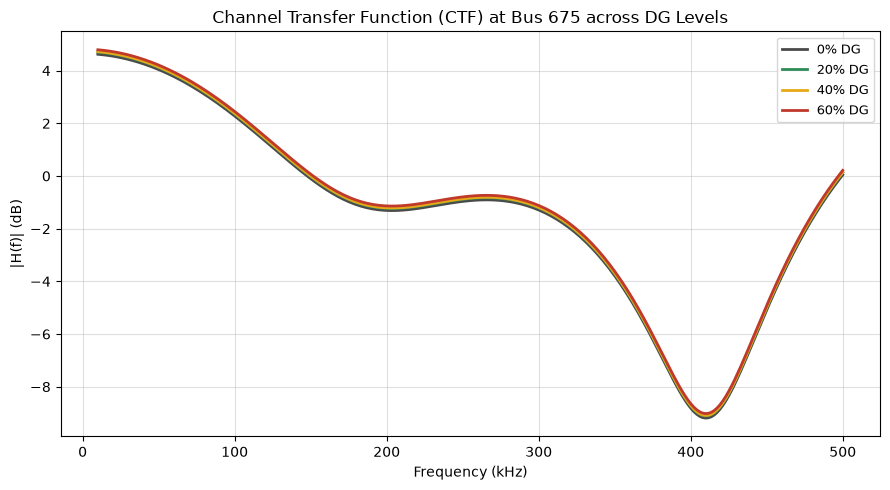

In [ ]:
# FIGURE 1: 24-Hour Stability
# Demonstrates whether accuracy changes as solar panels inject power during the day.

X_test_with_hour = ml_df.loc[X_test.index]
hours = sorted(X_test_with_hour["hour"].dropna().unique())
rf_acc_hour, knn_acc_hour = [], []

for hour in hours:
    mask = X_test_with_hour["hour"] == hour
    if mask.any():
        X_test_hour = X_test_with_hour.loc[mask, feature_cols]
        rf_acc_hour.append(accuracy_score(y_test.loc[mask], rf_model.predict(X_test_hour)))
        knn_acc_hour.append(accuracy_score(y_test.loc[mask], knn_model.predict(X_test_hour)))
    else:
        rf_acc_hour.append(0)
        knn_acc_hour.append(0)

plt.figure(figsize=(9, 5))
plt.plot(hours, [acc * 100 for acc in rf_acc_hour], marker="o", label="Random Forest (Proposed)", color="#2b6cb0", linewidth=2)
plt.plot(hours, [acc * 100 for acc in knn_acc_hour], marker="s", linestyle="--", label="KNN (Baseline)", color="#a6a6a6", linewidth=2)
plt.xticks(hours)
plt.xlabel("Time of Day (Hour)")
plt.ylabel("Topology Inference Accuracy (%)")
plt.title("24-Hour Inference Stability under Variable DG Integration")
plt.legend(loc="lower right")
plt.grid(True, alpha=0.4)
plt.ylim(0, 105)
plt.tight_layout()
plt.savefig(TEL_FIG_DIR / "accuracy_vs_hour.png", dpi=300)
plt.show()


### FIGURE 2: Node Localization Error (Meters)
When the classifier fails, this metric measures how far away the predicted bus is physically.


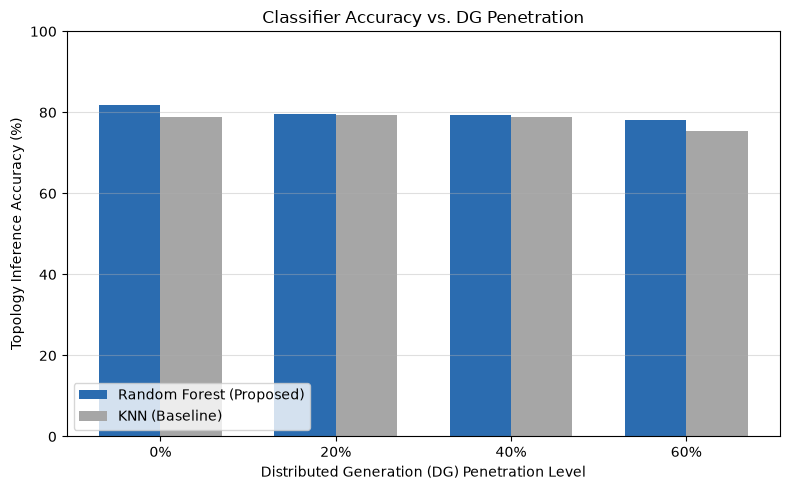

In [ ]:
# FIGURE 2: Node Localization Error (Meters)
bus_distances = (
    data.dropna(subset=["distance_km"])
    .drop_duplicates(subset=["bus"])
    .set_index("bus")["distance_km"]
    .to_dict()
)

true_distances_m = [bus_distances.get(bus, 0) * 1000 for bus in y_test]
pred_distances_m = [bus_distances.get(bus, 0) * 1000 for bus in rf_preds]

errors_m = np.abs(np.array(true_distances_m) - np.array(pred_distances_m))
misclassified_mask = y_test.to_numpy() != rf_preds
mean_error_wrong = np.mean(errors_m[misclassified_mask]) if misclassified_mask.any() else 0.0

print("=== Localization Error Metrics (Random Forest) ===")
print(f"Mean Error (All samples): {np.mean(errors_m):.2f} meters")
print(f"Mean Error (Only when misclassified): {mean_error_wrong:.2f} meters")


### FIGURE 3: Accuracy vs. DG Penetration
This figure compares classifier accuracy across distributed-generation penetration levels.


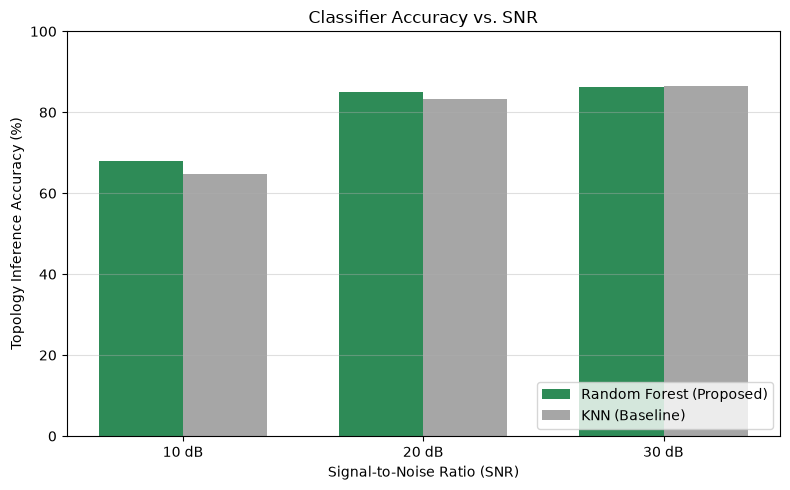

In [ ]:
# FIGURE 3: Accuracy vs DG Penetration
dg_levels = sorted(ml_df["dg_penetration"].dropna().unique())
rf_acc_dg, knn_acc_dg = [], []

for dg in dg_levels:
    mask = X_test["dg_penetration"] == dg
    if mask.any():
        rf_acc_dg.append(accuracy_score(y_test.loc[mask], rf_model.predict(X_test.loc[mask])))
        knn_acc_dg.append(accuracy_score(y_test.loc[mask], knn_model.predict(X_test.loc[mask])))
    else:
        rf_acc_dg.append(0)
        knn_acc_dg.append(0)

x = np.arange(len(dg_levels))
width = 0.35

plt.figure(figsize=(8, 5))
plt.bar(x - width/2, [acc * 100 for acc in rf_acc_dg], width, label="Random Forest (Proposed)", color="#2b6cb0")
plt.bar(x + width/2, [acc * 100 for acc in knn_acc_dg], width, label="KNN (Baseline)", color="#a6a6a6")
plt.xticks(x, [f"{dg:g}%" for dg in dg_levels])
plt.xlabel("Distributed Generation (DG) Penetration Level")
plt.ylabel("Topology Inference Accuracy (%)")
plt.title("Classifier Accuracy vs. DG Penetration")
plt.legend(loc="lower left")
plt.grid(axis="y", alpha=0.4)
plt.ylim(0, 100)
plt.tight_layout()
plt.savefig(TEL_FIG_DIR / "accuracy_vs_dg.png", dpi=300)
plt.show()


### FIGURE 4: Accuracy vs. Signal-to-Noise Ratio (SNR)
This figure measures classifier resilience to telecom noise at different SNR levels.


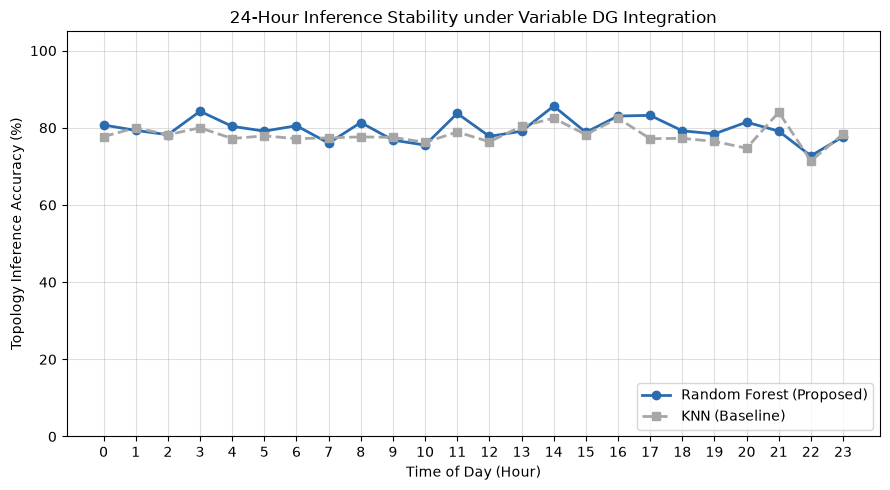

In [ ]:
# FIGURE 4: Accuracy vs SNR
snr_levels = sorted(ml_df["snr_db"].dropna().unique())
rf_acc_snr, knn_acc_snr = [], []

for snr in snr_levels:
    mask = X_test["snr_db"] == snr
    if mask.any():
        rf_acc_snr.append(accuracy_score(y_test.loc[mask], rf_model.predict(X_test.loc[mask])))
        knn_acc_snr.append(accuracy_score(y_test.loc[mask], knn_model.predict(X_test.loc[mask])))
    else:
        rf_acc_snr.append(0)
        knn_acc_snr.append(0)

x = np.arange(len(snr_levels))
width = 0.35

plt.figure(figsize=(8, 5))
plt.bar(x - width/2, [acc * 100 for acc in rf_acc_snr], width, label="Random Forest (Proposed)", color="#2e8b57")
plt.bar(x + width/2, [acc * 100 for acc in knn_acc_snr], width, label="KNN (Baseline)", color="#a6a6a6")
plt.xticks(x, [f"{snr:g} dB" for snr in snr_levels])
plt.xlabel("Signal-to-Noise Ratio (SNR)")
plt.ylabel("Topology Inference Accuracy (%)")
plt.title("Classifier Accuracy vs. SNR")
plt.legend(loc="lower right")
plt.grid(axis="y", alpha=0.4)
plt.ylim(0, 100)
plt.tight_layout()
plt.savefig(TEL_FIG_DIR / "accuracy_vs_snr.png", dpi=300)
plt.show()
